# Healthcare Claim Anomaly Detection — HDBSCAN + GLOSH (Provider Level)

**Cameroon openIMIS · Hospital-Month Aggregation**

This notebook adapts the core parsing and data ingestion pipeline from the isolation forest model but shifts the target from individual claims to **systemic, provider-level behavior**. 
Instead of scoring 14.2M claims individually, we aggregate them into ~30,000 **hospital-month profiles**.

We then apply **HDBSCAN** clustering and use **GLOSH** (Global-Local Outlier Score from Hierarchies) to identify anomalous behavior.

## Why HDBSCAN + GLOSH for this problem?
| | HDBSCAN + GLOSH | 
|---|---|
| Use Case | Detecting systemic fraud (e.g. upcoding, billing dumps, uniform patterns) across an entire facility. |
| Grouping | `Hfid` + `Month(DateClaimed)` |
| Distance Metric | Handles complex geometries without assuming spherical clusters (unlike K-Means). |
| GLOSH Outlier Score | Extremely effective at finding **local anomalies**. It can flag a small rural clinic behaving slightly like a huge urban hospital, even if its absolute volumes aren't globally extreme. |
| Interpretability | Native GLOSH scores, supplemented by a LightGBM surrogate model trained on the top outliers to provide SHAP feature importance. |

---
## Pipeline Overview
1. **Data Ingestion**: Identical robust parser to the baseline notebooks (handling unicode spaces in money, `NaT` cascading).
2. **Aggregation**: Claims are grouped by `Hfid` and `DateClaimed` (Month).
3. **Feature Engineering**: Volume, cost averages, behavioral anomaly proportions (e.g. % backdated).
4. **Scaling**: `RobustScaler` to limit the massive pull of ultra-high volume hospitals.
5. **Clustering & Scoring**: `hdbscan.HDBSCAN(gen_min_span_tree=True)`, extracting `.outlier_scores_`.
6. **Explaining**: LightGBM Surrogate + SHAP for top anomalies.
\n

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----------------------------- ---------- 7.3/9.8 MB 40.4 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 38.5 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 64.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 15.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------------------------- ------ 6.0/7.2 MB 30.4 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 28.4 MB/s  0:00:00

   ----------------------------------------  0/10 [tzdata]
   ----------------------------------------  0/10 [tzdata]
   ---- -----------------------------------  1/10 [pyparsing]
   -------- -------------------------------  2/10 [pillow]
   -------- ----------------------

In [6]:
!pip install pandas lightgbm


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 7.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -----------

In [7]:
import os, gc, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Ensure hdbscan and lightgbm are available
try:
    import hdbscan
except ImportError:
    !pip install hdbscan
    import hdbscan

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import lightgbm as lgb

try:
    import shap
except ImportError:
    !pip install shap
    import shap

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

CONFIG = {
    # ---- paths -------------------------------------------------------------
    "DATA_DIR":  r"C:\Projects\cameroon 3.0\data", # Fallback, will be replaced if different
    "MODEL_DIR": r"C:\Projects\cameroon 3.0\model_hdbscan",

    # ---- D9: which claim statuses count as adjudicated ----------------------
    "ACCEPTED_STATUSES": (16, 32),
    "REJECTED_STATUSES": (1,),

    # ---- D2/D22: parsing ---------------------------------------------------
    "MONEY_HAS_DECIMALS": False,
    "MAX_MONEY_UNPARSEABLE_RATE": 0.01,
    "MAX_DATE_NAT_RATE":          0.05,

    # ---- HDBSCAN -----------------------------------------------------------
    "HDBSCAN_MIN_CLUSTER_SIZE": 30,
    "HDBSCAN_MIN_SAMPLES": 15,
    
    # ---- Surrogate Model ---------------------------------------------------
    "TOP_OUTLIER_PERCENTILE": 95, # Train surrogate on top 5% of GLOSH scores

    # ---- runtime -----------------------------------------------------------
    "CHUNK_SIZE":  2_000_000,
    "SEED": 42
}

# Auto-detect real paths if run on another machine
_local_data_dir = r"h:\SSD_Backup\Cameroon 2nd Report Codes\data"
if os.path.exists(_local_data_dir):
    CONFIG["DATA_DIR"] = _local_data_dir

DATA_DIR  = Path(CONFIG["DATA_DIR"])
MODEL_DIR = Path(CONFIG["MODEL_DIR"]); MODEL_DIR.mkdir(parents=True, exist_ok=True)
CLAIM_FILE    = DATA_DIR / "TblClaim.csv"
SERVICES_FILE = DATA_DIR / "TblClaimServices.csv"
HF_FILE       = DATA_DIR / "TblHF.csv"

np.random.seed(CONFIG["SEED"])


   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   -------- ------------------------------- 8.4/41.9 MB 44.4 MB/s eta 0:00:01
   ----------------- ---------------------- 18.6/41.9 MB 47.4 MB/s eta 0:00:01
   ------------------ --------------------- 19.1/41.9 MB 34.2 MB/s eta 0:00:01
   ---------------------------- ----------- 29.4/41.9 MB 36.4 MB/s eta 0:00:01
   ------------------------------------- -- 39.3/41.9 MB 39.3 MB/s eta 0:00:01
   ---------------------------------------  41.7/41.9 MB 38.6 MB/s eta 0:00:01
   ---------------------------------------- 41.9/41.9 MB 32.4 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 45.9 MB/s  0:00:00

   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
 

c:\Users\Samin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# ---------------------------------------------------------------------------
# Helper functions (Identical to Isolation Forest Notebook)
# ---------------------------------------------------------------------------

_SPACE_CHARS = r"[\s\u00A0\u202F\u2009\u2007]"

def parse_money(s: pd.Series, has_decimals: bool = None) -> pd.Series:
    if has_decimals is None:
        has_decimals = CONFIG["MONEY_HAS_DECIMALS"]
    if pd.api.types.is_numeric_dtype(s):
        return s.astype("float64")

    t = s.astype("string").str.strip()
    t = t.str.replace(_SPACE_CHARS, "", regex=True)
    t = t.str.replace(r"[^\d\.,\-]", "", regex=True)

    if has_decimals:
        t = t.str.replace(r"[\.,](?=\d{3}(?:\D|$))", "", regex=True)
        t = t.str.replace(",", ".", regex=False)
    else:
        t = t.str.replace(r"[\.,]", "", regex=True)

    t = t.replace({"": pd.NA, "-": pd.NA})
    return pd.to_numeric(t, errors="coerce").astype("float64")

DATE_FORMATS = [
    "%d %b, %Y, %H:%M", "%d %b, %Y, %H:%M:%S", "%d %b, %Y",
    "%Y-%m-%d %H:%M:%S.%f", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d",
    "%d/%m/%Y %H:%M", "%d/%m/%Y", "%m/%d/%Y",
]

def parse_dates(s: pd.Series, formats=DATE_FORMATS) -> pd.Series:
    if pd.api.types.is_datetime64_any_dtype(s):
        return s
    t = s.astype("string").str.strip()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    todo = out.isna() & t.notna()
    for fmt in formats:
        if not todo.any():
            break
        parsed = pd.to_datetime(t[todo], format=fmt, errors="coerce")
        out.loc[todo] = parsed
        todo = out.isna() & t.notna()
    if todo.any():
        try:
            out.loc[todo] = pd.to_datetime(t[todo], errors="coerce", format="mixed", dayfirst=True)
        except:
            out.loc[todo] = pd.to_datetime(t[todo], errors="coerce", dayfirst=True)
    return out


In [11]:
# ---------------------------------------------------------------------------
# Data Ingestion & Claim-Level Processing
# ---------------------------------------------------------------------------
print("Aggregating TblClaimServices.csv ...")
df_services = pd.read_csv(SERVICES_FILE, usecols=["ClaimID", "PriceAsked"], dtype={"PriceAsked": str}, low_memory=False)
df_services["PriceAsked"] = parse_money(df_services["PriceAsked"])
srv_agg = (df_services.groupby("ClaimID")["PriceAsked"]
           .agg(SVC_Count="count", SVC_TotalAsked="sum")
           .reset_index())
del df_services; gc.collect()

print("Ingesting TblClaim.csv ...")
USECOLS = ["ClaimID", "ClaimStatus", "Claimed", "DateFrom", "DateTo", "DateClaimed", "Hfid", "CareType"]
KEEP_STATUS = set(CONFIG["ACCEPTED_STATUSES"]) | set(CONFIG["REJECTED_STATUSES"])

chunks = []
for i, ch in enumerate(pd.read_csv(CLAIM_FILE, usecols=USECOLS, dtype=str, chunksize=CONFIG["CHUNK_SIZE"], low_memory=False)):
    ch["ClaimID"] = pd.to_numeric(ch["ClaimID"], errors="coerce")
    ch["ClaimStatus"] = pd.to_numeric(ch["ClaimStatus"], errors="coerce")
    ch = ch[ch["ClaimStatus"].isin(KEEP_STATUS)].copy()
    if ch.empty: continue
        
    ch["IsRejected"] = ch["ClaimStatus"].isin(CONFIG["REJECTED_STATUSES"]).astype(int)
    ch["Hfid"] = pd.to_numeric(ch["Hfid"], errors="coerce").fillna(-1).astype(int)
    
    # Merge Services
    ch = ch.merge(srv_agg, on="ClaimID", how="left")
    ch["NoServiceLines"] = ch["SVC_Count"].isna().astype(int)
    
    # Parse Money & Dates
    ch["ClaimedAmount"] = parse_money(ch["Claimed"])
    ch["DateFrom_p"] = parse_dates(ch["DateFrom"])
    ch["DateTo_p"] = parse_dates(ch["DateTo"])
    ch["DateClaimed_p"] = parse_dates(ch["DateClaimed"])
    
    # Feature Engineering
    los = (ch["DateTo_p"] - ch["DateFrom_p"]).dt.days
    delay = (ch["DateClaimed_p"] - ch["DateTo_p"]).dt.days
    
    ch["IsNegLOS"] = (los < 0).fillna(False).astype(int)
    ch["IsBackdated"] = (delay < 0).fillna(False).astype(int)
    ch["LengthOfStay"] = los
    ch["SubmissionDelay"] = delay
    ch["IsIPD"] = (ch["CareType"] == "IPD").astype(int)
    
    # Extract Month Profile
    ch["ProfileMonth"] = ch["DateClaimed_p"].dt.to_period("M")
    
    keep = ["Hfid", "ProfileMonth", "ClaimID", "IsRejected", "ClaimedAmount", "LengthOfStay", 
            "SubmissionDelay", "SVC_Count", "IsNegLOS", "IsBackdated", "NoServiceLines", "IsIPD"]
    chunks.append(ch[keep])
    print(f"  Chunk {i+1} processed.")

df_claims = pd.concat(chunks, ignore_index=True)
del chunks, srv_agg; gc.collect()
print(f"Total Adjudicated Claims loaded: {len(df_claims):,}")


Aggregating TblClaimServices.csv ...
Ingesting TblClaim.csv ...
  Chunk 1 processed.
  Chunk 2 processed.
  Chunk 3 processed.
  Chunk 4 processed.
  Chunk 5 processed.
  Chunk 6 processed.
  Chunk 7 processed.
  Chunk 8 processed.
Total Adjudicated Claims loaded: 2,785,424


In [13]:
# ---------------------------------------------------------------------------
# Hospital-Month Profile Aggregation
# ---------------------------------------------------------------------------
print("Aggregating into Hospital-Month Profiles...")
df_claims = df_claims.dropna(subset=["ProfileMonth", "Hfid"])
df_claims["ProfileMonth"] = df_claims["ProfileMonth"].astype(str) # For groupby

profiles = df_claims.groupby(["Hfid", "ProfileMonth"]).agg(
    TotalClaims=("ClaimID", "count"),
    TotalClaimed=("ClaimedAmount", "sum"),
    RejectionRate=("IsRejected", "mean"),
    MeanClaimAmount=("ClaimedAmount", "mean"),
    MaxClaimAmount=("ClaimedAmount", "max"),
    MeanLOS=("LengthOfStay", "mean"),
    MeanDelay=("SubmissionDelay", "mean"),
    MeanServices=("SVC_Count", "mean"),
    PctNegLOS=("IsNegLOS", "mean"),
    PctBackdated=("IsBackdated", "mean"),
    PctNoServices=("NoServiceLines", "mean"),
    PctIPD=("IsIPD", "mean")
).reset_index()

# Filter out extreme micro-months (e.g. months with < 10 claims) 
# as they will create enormous variance in percentages (1 reject out of 1 claim = 100%)
# For auditing, we care about systemic fraud, so minimum volume is required.
MIN_CLAIMS_FOR_PROFILE = 20
profiles = profiles[profiles["TotalClaims"] >= MIN_CLAIMS_FOR_PROFILE].copy()

# Fill NaNs generated by all-NaN means (e.g., all claims missing LOS)
profiles = profiles.fillna(0)

# Log transform heavy-tailed monetary/volume variables
for col in ["TotalClaims", "TotalClaimed", "MeanClaimAmount", "MaxClaimAmount"]:
    profiles[col + "_log"] = np.log1p(profiles[col].clip(lower=0))

features = [
    "TotalClaims_log", "TotalClaimed_log", "RejectionRate", "MeanClaimAmount_log", 
    "MaxClaimAmount_log", "MeanLOS", "MeanDelay", "MeanServices", 
    "PctNegLOS", "PctBackdated", "PctNoServices", "PctIPD"
]

print(f"Created {len(profiles):,} valid hospital-month profiles.")


Aggregating into Hospital-Month Profiles...
Created 11,160 valid hospital-month profiles.


In [14]:
# ---------------------------------------------------------------------------
# HDBSCAN Clustering & GLOSH Outlier Scoring
# ---------------------------------------------------------------------------

X = profiles[features].values

# Scale features. RobustScaler is vital here to prevent massive hospitals 
# from stretching the distance space too far.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("Training HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=CONFIG["HDBSCAN_MIN_CLUSTER_SIZE"], 
    min_samples=CONFIG["HDBSCAN_MIN_SAMPLES"], 
    gen_min_span_tree=True
)
clusterer.fit(X_scaled)

profiles["Cluster"] = clusterer.labels_
profiles["GLOSH_Score"] = clusterer.outlier_scores_
profiles["Anomaly_Probability"] = clusterer.probabilities_

n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
n_noise = list(clusterer.labels_).count(-1)

print(f"HDBSCAN found {n_clusters} clusters.")
print(f"Points classified as global noise (-1): {n_noise} ({n_noise/len(profiles):.1%})")

# Rank the profiles by GLOSH score for audit targeting
audit_targets = profiles.sort_values("GLOSH_Score", ascending=False).reset_index(drop=True)
audit_targets.head(15)[["Hfid", "ProfileMonth", "Cluster", "GLOSH_Score", "TotalClaims", "TotalClaimed", "RejectionRate"]]


Training HDBSCAN...
HDBSCAN found 8 clusters.
Points classified as global noise (-1): 5629 (50.4%)


,Hfid,ProfileMonth,Cluster,GLOSH_Score,TotalClaims,TotalClaimed,RejectionRate
0,359,2025-05,-1,0.999995,108,208290.0,0.194444
1,352,2026-01,-1,0.999710,2142,4727100.0,0.180672
2,3890,2026-01,-1,0.999646,113,758200.0,0.867257
3,703,2025-06,-1,0.999047,22,77500.0,0.863636
4,3890,2025-10,-1,0.998991,345,2334000.0,0.881159
5,1068,2026-02,-1,0.998967,104,444900.0,0.461538
6,382,2024-12,-1,0.998840,113,746100.0,0.035398
7,583,2025-10,-1,0.998669,35,56100.0,0.342857
8,3662,2025-10,-1,0.998458,42,185500.0,0.404762
9,703,2025-11,-1,0.998375,1804,8436275.0,0.565410



   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]

Running UMAP for visualization...


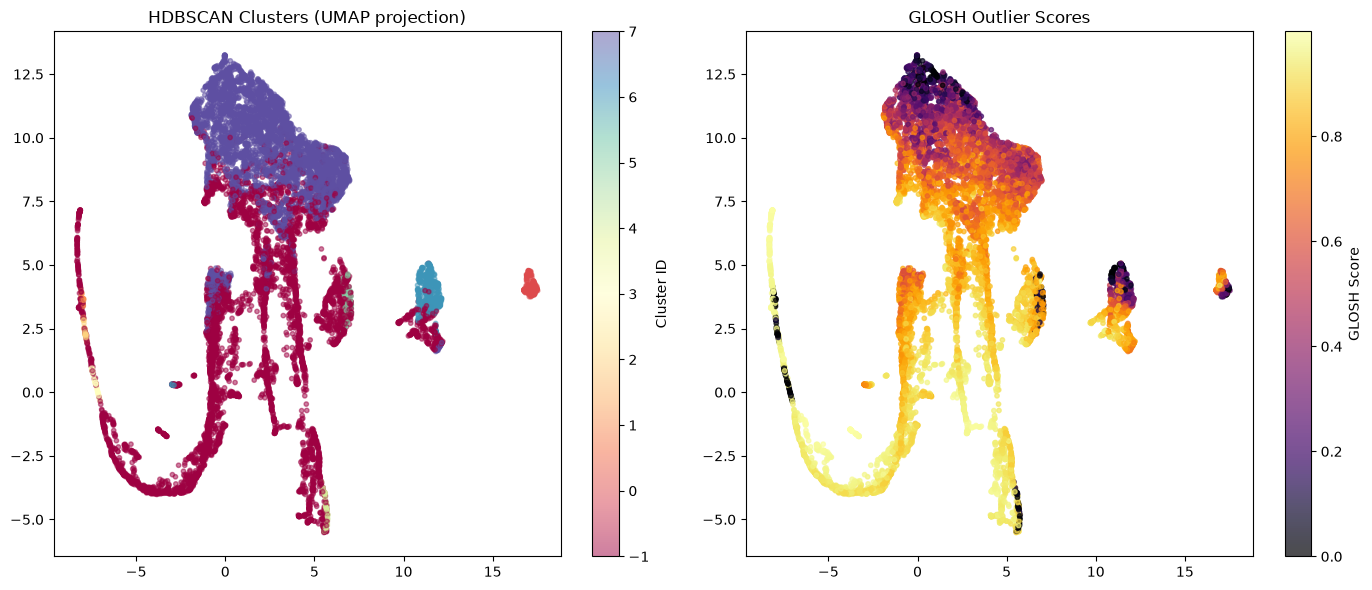

In [15]:
# ---------------------------------------------------------------------------
# Visualization: UMAP Projection
# ---------------------------------------------------------------------------
try:
    import umap
except ImportError:
    !pip install umap-learn
    import umap

print("Running UMAP for visualization...")
reducer = umap.UMAP(n_components=2, random_state=CONFIG["SEED"])
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# Plot 1: Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=profiles["Cluster"], cmap="Spectral", s=10, alpha=0.5)
plt.title("HDBSCAN Clusters (UMAP projection)")
plt.colorbar(scatter, label="Cluster ID")

# Plot 2: GLOSH Outlier Scores
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(embedding[:, 0], embedding[:, 1], c=profiles["GLOSH_Score"], cmap="inferno", s=10, alpha=0.7)
plt.title("GLOSH Outlier Scores")
plt.colorbar(scatter2, label="GLOSH Score")

plt.tight_layout()
plt.show()


In [21]:
# ---------------------------------------------------------------------------
# Surrogate Explainer: LightGBM + SHAP
# ---------------------------------------------------------------------------
# HDBSCAN does not natively explain *why* a point has a high GLOSH score.
# To provide actionable insights to auditors, we train a surrogate LightGBM classifier 
# to predict if a profile is in the top N% of GLOSH outliers.
# We then use TreeSHAP to explain the model's decision for the top anomalies.

threshold = np.percentile(profiles["GLOSH_Score"].dropna(), CONFIG["TOP_OUTLIER_PERCENTILE"])
y_surrogate = (profiles["GLOSH_Score"] >= threshold).astype(int)

lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=CONFIG["SEED"], max_depth=4)
lgb_model.fit(X, y_surrogate)

print(f"Surrogate model trained to identify top {100-CONFIG['TOP_OUTLIER_PERCENTILE']}% anomalies.")

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X)

# Explain the most anomalous profile
idx_most_anomalous = audit_targets.index[0] 
print(f"\n--- Explaining the #1 Anomaly: Hfid {audit_targets.loc[0, 'Hfid']} in {audit_targets.loc[0, 'ProfileMonth']} ---")


[LightGBM] [Info] Number of positive: 558, number of negative: 10602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000513 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2345
[LightGBM] [Info] Number of data points in the train set: 11160, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050000 -> initscore=-2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,